<a href="https://colab.research.google.com/github/mahimore21-cmd/galentine/blob/main/automated_image.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.applications.inception_v3 import (
    InceptionV3,
    preprocess_input
)

from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Add
from tensorflow.keras.models import Model

print("TensorFlow version:", tf.__version__)
print("Libraries loaded successfully!")

TensorFlow version: 2.20.0
Libraries loaded successfully!


In [2]:
!wget -q https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_Dataset.zip
!wget -q https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_text.zip

!unzip -q Flickr8k_Dataset.zip
!unzip -q Flickr8k_text.zip

print("Dataset downloaded and extracted!")

Dataset downloaded and extracted!


In [3]:
image_folder = "Flicker8k_Dataset"
caption_file = "Flickr8k.token.txt"

print("Image folder exists:", os.path.exists(image_folder))
print("Caption file exists:", os.path.exists(caption_file))

images = os.listdir(image_folder)

print("Number of images:", len(images))
print("First image:", images[0])

Image folder exists: True
Caption file exists: True
Number of images: 8091
First image: 431018958_84b2beebff.jpg


In [4]:
captions = {}

with open(caption_file, "r") as file:

    for line in file:

        parts = line.strip().split("\t")

        if len(parts) != 2:
            continue

        image_name = parts[0].split("#")[0]
        caption = parts[1]

        if image_name not in captions:
            captions[image_name] = []

        captions[image_name].append(caption)

print("Images with captions:", len(captions))

Images with captions: 8092


In [5]:
clean_captions = {}

for image_name, caption_list in captions.items():

    clean_captions[image_name] = []

    for caption in caption_list:

        caption = caption.lower()

        caption = caption.replace(".", "")
        caption = caption.replace(",", "")
        caption = caption.replace("!", "")
        caption = caption.replace("?", "")

        caption = "startseq " + caption + " endseq"

        clean_captions[image_name].append(caption)

print("Example caption:")
print(clean_captions[list(clean_captions.keys())[0]][0])

Example caption:
startseq a child in a pink dress is climbing up a set of stairs in an entry way  endseq


In [6]:
all_images = list(clean_captions.keys())

np.random.seed(42)
np.random.shuffle(all_images)

selected_images = all_images[:300]

train_images = selected_images[:250]
test_images = selected_images[250:]

print("Training images:", len(train_images))
print("Testing images:", len(test_images))

Training images: 250
Testing images: 50


In [7]:
all_training_captions = []

for image_name in train_images:
    all_training_captions.extend(
        clean_captions[image_name]
    )

tokenizer = Tokenizer(
    oov_token="<unk>"
)

tokenizer.fit_on_texts(all_training_captions)

vocab_size = len(tokenizer.word_index) + 1

max_length = max(
    len(tokenizer.texts_to_sequences([caption])[0])
    for caption in all_training_captions
)

print("Vocabulary size:", vocab_size)
print("Maximum caption length:", max_length)

Vocabulary size: 1515
Maximum caption length: 33


In [8]:
base_cnn = InceptionV3(
    weights="imagenet",
    include_top=True
)

cnn_encoder = Model(
    inputs=base_cnn.input,
    outputs=base_cnn.layers[-2].output
)

feature_size = cnn_encoder.output_shape[-1]

print("CNN encoder ready!")
print("Feature size:", feature_size)

96112376/96112376 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
CNN encoder ready!
Feature size: 2048


In [9]:
def extract_features(image_list):

    features = {}

    for count, image_name in enumerate(image_list):

        path = os.path.join(image_folder, image_name)

        image = load_img(
            path,
            target_size=(299, 299)
        )

        image = img_to_array(image)

        image = np.expand_dims(image, axis=0)

        image = preprocess_input(image)

        feature = cnn_encoder.predict(
            image,
            verbose=0
        )

        features[image_name] = feature[0]

        if (count + 1) % 25 == 0:
            print("Processed:", count + 1)

    return features


train_features = extract_features(train_images)
test_features = extract_features(test_images)

print("Training features:", len(train_features))
print("Testing features:", len(test_features))

Processed: 25
Processed: 50
Processed: 75
Processed: 100
Processed: 125
Processed: 150
Processed: 175
Processed: 200
Processed: 225
Processed: 250
Processed: 25
Processed: 50
Training features: 250
Testing features: 50


In [10]:
X_image = []
X_text = []
y = []

for image_name in train_images:

    feature = train_features[image_name]

    for caption in clean_captions[image_name]:

        sequence = tokenizer.texts_to_sequences(
            [caption]
        )[0]

        for i in range(1, len(sequence)):

            input_sequence = sequence[:i]
            output_word = sequence[i]

            X_image.append(feature)
            X_text.append(input_sequence)
            y.append(output_word)

X_image = np.array(X_image, dtype="float32")

X_text = pad_sequences(
    X_text,
    maxlen=max_length,
    padding="post"
)

y = np.array(y)

print("Image input shape:", X_image.shape)
print("Text input shape:", X_text.shape)
print("Output shape:", y.shape)

Image input shape: (14554, 2048)
Text input shape: (14554, 33)
Output shape: (14554,)


In [11]:
# CNN input
image_input = Input(
    shape=(feature_size,),
    name="image_input"
)

image_dense = Dense(
    256,
    activation="relu"
)(image_input)


# LSTM input
text_input = Input(
    shape=(max_length,),
    name="text_input"
)

text_embedding = Embedding(
    input_dim=vocab_size,
    output_dim=256,
    mask_zero=True
)(text_input)

text_lstm = LSTM(256)(
    text_embedding
)


# Combine CNN + LSTM
combined = Add()([
    image_dense,
    text_lstm
])

output = Dense(
    vocab_size,
    activation="softmax"
)(combined)


model = Model(
    inputs=[image_input, text_input],
    outputs=output
)

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy"
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_input          │ (None, 33)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_input         │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 33, 256)   │    387,840 │ text_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 33)        │          0 │ text_input[0][0]  │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    524,544 │ image_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 256)       │    525,312 │ embedding[0][0],  │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256)       │          0 │ dense[0][0],      │
│                     │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1515)      │    389,355 │ add[0][0]         │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,827,051 (6.97 MB)

 Trainable params: 1,827,051 (6.97 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
history = model.fit(
    [X_image, X_text],
    y,
    epochs=3,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/3
205/205 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5.0203 - val_loss: 4.7387
Epoch 2/3
205/205 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 3.7920 - val_loss: 4.4733
Epoch 3/3
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.0785 - val_loss: 4.4672


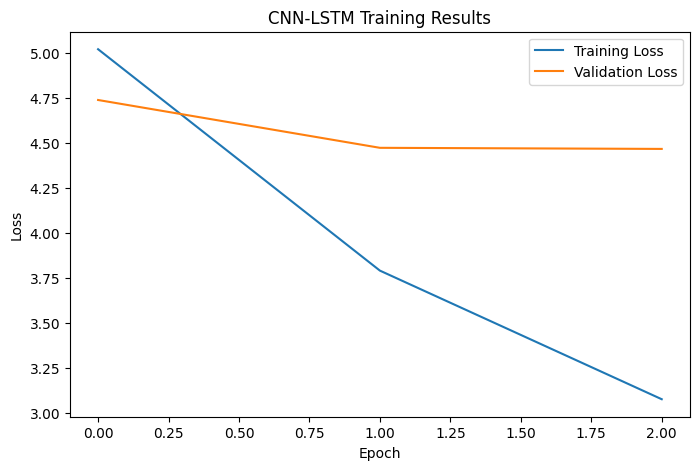

In [13]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN-LSTM Training Results")

plt.legend()
plt.show()

In [14]:
def generate_caption(image_name):

    feature = test_features[image_name]

    words = ["startseq"]

    for _ in range(max_length):

        sequence = tokenizer.texts_to_sequences(
            [" ".join(words)]
        )[0]

        sequence = pad_sequences(
            [sequence],
            maxlen=max_length,
            padding="post"
        )

        prediction = model.predict(
            [
                np.array([feature]),
                sequence
            ],
            verbose=0
        )[0]

        word_id = np.argmax(prediction)

        word = tokenizer.index_word.get(word_id)

        if word is None:
            break

        if word == "endseq":
            break

        words.append(word)

    return " ".join(words[1:])

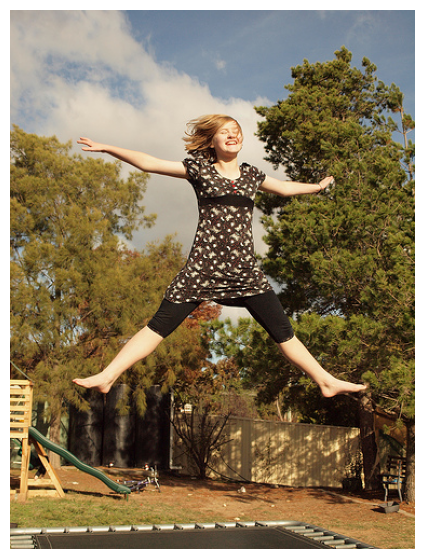

Actual Caption:
startseq a girl doing the splits in the air while jumping on a trampoline  endseq

Generated Caption:
a little girl in a red shirt is playing in the grass


In [15]:
test_image = test_images[0]

image_path = os.path.join(
    image_folder,
    test_image
)

image = load_img(image_path)

plt.figure(figsize=(10,7))

plt.imshow(image)
plt.axis("off")
plt.show()

print("Actual Caption:")
print(clean_captions[test_image][0])

print("\nGenerated Caption:")
print(generate_caption(test_image))

In [16]:
from tensorflow.keras.applications.inception_v3 import preprocess_input

In [ ]:
# ============================================
# FINAL FRONTEND + BACKEND CONNECTION
# ============================================

import gradio as gr
import numpy as np
from PIL import Image
import traceback


def generate_caption(image):

    try:

        # -----------------------------
        # STEP 1: Check image
        # -----------------------------

        if image is None:
            return "Please upload an image."


        # -----------------------------
        # STEP 2: Convert image to RGB
        # -----------------------------

        image = image.convert("RGB")


        # -----------------------------
        # STEP 3: Resize image
        # -----------------------------

        image = image.resize((299, 299))


        # -----------------------------
        # STEP 4: Convert to NumPy
        # -----------------------------

        image_array = np.array(
            image,
            dtype=np.float32
        )


        # -----------------------------
        # STEP 5: Add batch dimension
        # -----------------------------

        image_array = np.expand_dims(
            image_array,
            axis=0
        )


        # -----------------------------
        # STEP 6: CNN preprocessing
        # -----------------------------

        image_array = preprocess_input(
            image_array
        )


        # -----------------------------
        # STEP 7: Extract CNN features
        # -----------------------------

        feature = cnn_encoder.predict(
            image_array,
            verbose=0
        )


        # -----------------------------
        # STEP 8: Start caption
        # -----------------------------

        caption = ["startseq"]


        # -----------------------------
        # STEP 9: Generate words
        # -----------------------------

        for i in range(max_length):

            text = " ".join(caption)

            sequence = tokenizer.texts_to_sequences(
                [text]
            )[0]


            sequence = pad_sequences(
                [sequence],
                maxlen=max_length,
                padding="post"
            )


            # LSTM prediction
            prediction = model.predict(
                [feature, sequence],
                verbose=0
            )


            # Get most probable word
            word_id = int(
                np.argmax(prediction[0])
            )


            word = tokenizer.index_word.get(
                word_id
            )


            # Safety checks
            if word is None:
                break

            if word == "startseq":
                continue

            if word == "endseq":
                break


            caption.append(word)


        # -----------------------------
        # STEP 10: Final caption
        # -----------------------------

        result = " ".join(
            caption[1:]
        )


        if result.strip() == "":
            return "Model did not generate a caption."


        return result


    except Exception as e:

        # SHOW THE REAL ERROR
        print("\n========== BACKEND ERROR ==========")
        traceback.print_exc()
        print("====================================")

        return (
            "ERROR: "
            + type(e).__name__
            + "\n\n"
            + str(e)
        )


# ============================================
# FRONTEND
# ============================================

app = gr.Interface(

    fn=generate_caption,

    inputs=gr.Image(
        type="pil",
        label="📷 Upload Travel Image"
    ),

    outputs=gr.Textbox(
        label="🤖 Generated Caption",
        lines=5
    ),

    title="🖼️ Automated Image Captioning",

    description=(
        "Upload a travel photograph and click "
        "'Generate Caption'."
    ),

    submit_btn="Generate Caption"
)


app.launch(
    share=True,
    debug=True
)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://ef21b13009b20a41a4.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
